# Lab 5: Understanding Model Behavior - Decision Trees, Random Forests & Naive Bayes

##  Learning Objectives

In this lab, you'll discover:
1. **Why** different models make different predictions on the same data
2. **How** model architecture affects performance and stability
3. **When** to choose one model over another

We'll use interactive visualizations and experiments to build intuition about these algorithms!

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, log_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


##  Part 1: Decision Trees vs Random Forests

### The Core Question: Why Does Ensemble Learning Work?

Imagine you're trying to predict whether it will rain tomorrow:
- **Decision Tree**: Like asking ONE weather expert who looks at all factors and makes a decision
- **Random Forest**: Like asking 200 weather experts, each looking at different aspects, then taking a vote

### Key Concepts We'll Explore:

1. **Bias-Variance Tradeoff**: The fundamental tension in machine learning
   - **High Bias**: Model is too simple (underfitting)
   - **High Variance**: Model is too sensitive to training data (overfitting)

2. **Overfitting in Deep Trees**: Why unlimited depth can be dangerous

3. **Ensemble Stability**: How averaging reduces variance

In [10]:
# Create a synthetic dataset with controlled complexity
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=5,      # Only 5 features actually matter
    n_redundant=5,        # 5 features are combinations of informative ones
    weights=[0.7, 0.3],   # Imbalanced classes (70-30 split)
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"📊 Dataset Shape:")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_train.shape[1]}")
print(f"   Class distribution: {np.bincount(y_train)}")

📊 Dataset Shape:
   Training samples: 1400
   Test samples: 600
   Features: 20
   Class distribution: [978 422]


###  Experiment 1: Single Decision Tree (Unlimited Depth)

**What happens when we let a tree grow without constraints?**

A decision tree with `max_depth=None` will keep splitting until:
- Each leaf is pure (contains only one class), OR
- It runs out of samples to split

This often leads to **overfitting** - the tree memorizes the training data!

In [12]:
from sklearn.tree import DecisionTreeClassifier

# Train an unrestricted decision tree
dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_train, y_train)

# Evaluate on both training and test sets
train_acc_dt = accuracy_score(y_train, dt.predict(X_train))
test_acc_dt = accuracy_score(y_test, dt.predict(X_test))

print(" Single Decision Tree Results:")
print(f"   Training Accuracy: {train_acc_dt:.4f}")
print(f"   Test Accuracy:     {test_acc_dt:.4f}")
print(f"   Gap (Overfitting): {train_acc_dt - test_acc_dt:.4f}")
print(f"   Tree Depth:        {dt.get_depth()}")
print(f"   Number of Leaves:  {dt.get_n_leaves()}")

print("\n  Notice: High training accuracy but lower test accuracy = OVERFITTING!")

 Single Decision Tree Results:
   Training Accuracy: 1.0000
   Test Accuracy:     0.8867
   Gap (Overfitting): 0.1133
   Tree Depth:        16
   Number of Leaves:  105

  Notice: High training accuracy but lower test accuracy = OVERFITTING!


###  Experiment 2: Random Forest (Ensemble of 200 Trees)

**How does Random Forest combat overfitting?**

Random Forest uses two key strategies:

1. **Bootstrap Aggregating (Bagging)**:
   - Each tree trains on a random sample (with replacement) of the data
   - This creates diversity among trees

2. **Random Feature Selection**:
   - At each split, only consider a random subset of features
   - Prevents trees from being too similar

**The Magic**: Individual trees may overfit, but their *average* prediction is stable!

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Train a random forest
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

# Evaluate on both training and test sets
train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Results:")
print(f"   Training Accuracy: {train_acc_rf:.4f}")
print(f"   Test Accuracy:     {test_acc_rf:.4f}")
print(f"   Gap (Overfitting): {train_acc_rf - test_acc_rf:.4f}")

print("\n Notice: Much smaller gap between training and test accuracy!")
print(f"\n Improvement over single tree: {(test_acc_rf - test_acc_dt)*100:.2f}%")

Random Forest Results:
   Training Accuracy: 1.0000
   Test Accuracy:     0.9183
   Gap (Overfitting): 0.0817

 Notice: Much smaller gap between training and test accuracy!

 Improvement over single tree: 3.17%


###  Visualization: Performance Comparison

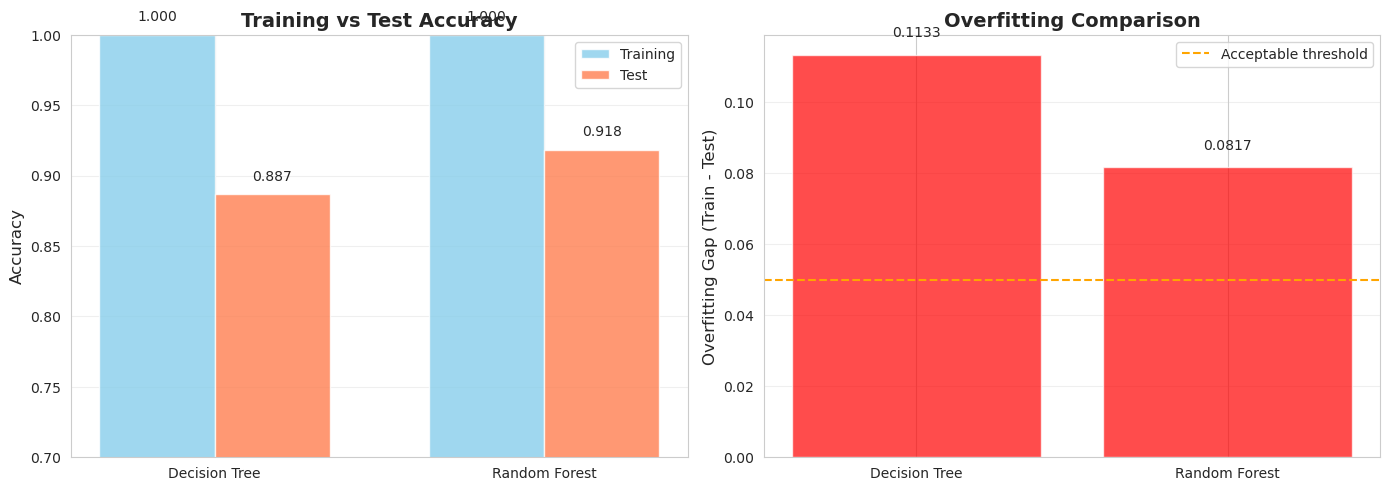


💡 Key Insight:
   Decision Tree: High training accuracy but significant drop on test data
   Random Forest: More balanced performance = better generalization!


In [14]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy Comparison
models = ['Decision Tree', 'Random Forest']
train_scores = [train_acc_dt, train_acc_rf]
test_scores = [test_acc_dt, test_acc_rf]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, train_scores, width, label='Training', alpha=0.8, color='skyblue')
axes[0].bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='coral')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim([0.7, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    axes[0].text(i - width/2, train + 0.01, f'{train:.3f}', ha='center', fontsize=10)
    axes[0].text(i + width/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=10)

# Plot 2: Overfitting Gap
gaps = [train_acc_dt - test_acc_dt, train_acc_rf - test_acc_rf]
colors = ['red' if gap > 0.05 else 'green' for gap in gaps]
axes[1].bar(models, gaps, color=colors, alpha=0.7)
axes[1].set_ylabel('Overfitting Gap (Train - Test)', fontsize=12)
axes[1].set_title('Overfitting Comparison', fontsize=14, fontweight='bold')
axes[1].axhline(y=0.05, color='orange', linestyle='--', label='Acceptable threshold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, gap in enumerate(gaps):
    axes[1].text(i, gap + 0.005, f'{gap:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print("   Decision Tree: High training accuracy but significant drop on test data")
print("   Random Forest: More balanced performance = better generalization!")

### 🔍 Experiment 3: Feature Importance Stability

**Why is feature importance unstable in Decision Trees but stable in Random Forests?**

Let's train multiple models with different random seeds and see how feature rankings change!

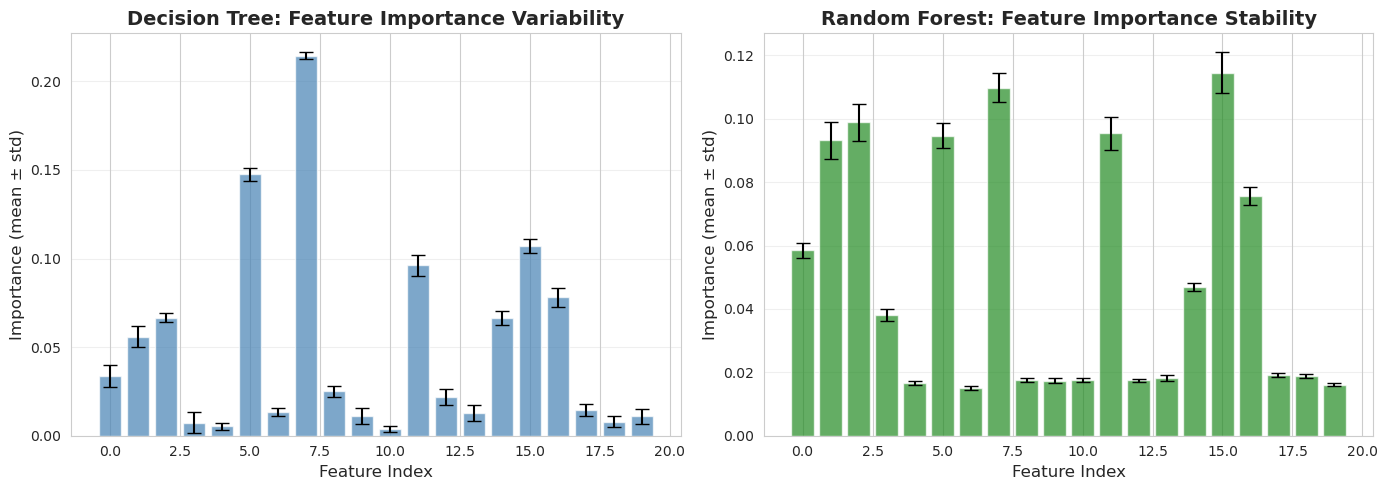


 Stability Metrics:
   Decision Tree - Avg Std Dev: 0.003914
   Random Forest - Avg Std Dev: 0.002326
   Stability Improvement: 40.6%

 Why the difference?
   Decision Tree: Small changes in data → completely different tree structure
   Random Forest: Averages 200 trees → individual variations cancel out!


In [16]:
# Train multiple models with different random seeds
n_trials = 10
dt_importances = []
rf_importances = []

for seed in range(n_trials):
    # Decision Tree
    dt_temp = DecisionTreeClassifier(max_depth=None, random_state=seed)
    dt_temp.fit(X_train, y_train)
    dt_importances.append(dt_temp.feature_importances_)
    
    # Random Forest
    rf_temp = RandomForestClassifier(n_estimators=200, random_state=seed)
    rf_temp.fit(X_train, y_train)
    rf_importances.append(rf_temp.feature_importances_)

# Convert to arrays
dt_importances = np.array(dt_importances)
rf_importances = np.array(rf_importances)

# Calculate standard deviation (measure of instability)
dt_std = dt_importances.std(axis=0)
rf_std = rf_importances.std(axis=0)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree importance variability
axes[0].bar(range(20), dt_importances.mean(axis=0), yerr=dt_std, 
            capsize=5, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Feature Index', fontsize=12)
axes[0].set_ylabel('Importance (mean ± std)', fontsize=12)
axes[0].set_title('Decision Tree: Feature Importance Variability', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Random Forest importance variability
axes[1].bar(range(20), rf_importances.mean(axis=0), yerr=rf_std, 
            capsize=5, alpha=0.7, color='forestgreen')
axes[1].set_xlabel('Feature Index', fontsize=12)
axes[1].set_ylabel('Importance (mean ± std)', fontsize=12)
axes[1].set_title('Random Forest: Feature Importance Stability', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Stability Metrics:")
print(f"   Decision Tree - Avg Std Dev: {dt_std.mean():.6f}")
print(f"   Random Forest - Avg Std Dev: {rf_std.mean():.6f}")
print(f"   Stability Improvement: {((dt_std.mean() - rf_std.mean()) / dt_std.mean() * 100):.1f}%")

print("\n Why the difference?")
print("   Decision Tree: Small changes in data → completely different tree structure")
print("   Random Forest: Averages 200 trees → individual variations cancel out!")

###  Discussion Questions

#### Q1: Why does Random Forest outperform Decision Tree?

**Answer**: Three main reasons:

1. **Variance Reduction**: 
   - Single tree: High variance (sensitive to training data)
   - Forest: Averaging 200 predictions reduces variance dramatically
   - Mathematical principle: Var(average) = Var(individual) / n (when independent)

2. **Decorrelation**:
   - Random feature selection ensures trees make different mistakes
   - Errors don't compound; they cancel out!

3. **Robustness to Noise**:
   - Single tree can be fooled by outliers
   - Forest requires majority of trees to be fooled

#### Q2: Why is feature importance unstable in DT but stable in RF?

**Answer**:
- **Decision Tree**: The first split has huge impact. If feature A is chosen first in one run but feature B in another, entire tree structure changes
- **Random Forest**: Even if individual trees disagree, the *average* importance converges to true signal

#### Q3: Why is RF more stable than DT?

**Answer**: 
- **Law of Large Numbers**: As we average more predictions, we approach the true expected value
- **Ensemble Diversity**: Different trees capture different patterns; averaging gives robust predictions
- **Analogy**: One person's opinion vs. survey of 200 people - which is more reliable?

##  Part 2: Naive Bayes - The Probabilistic Approach

### A Different Philosophy: Probabilistic vs Deterministic

**Decision Trees/Random Forests**: 
- "This sample belongs to class 1" (hard decision)
- Based on learned rules

**Naive Bayes**: 
- "This sample has 73% probability of being class 1" (soft decision)
- Based on Bayes' theorem

### Key Concepts:

1. **Conditional Independence Assumption**:
   - "Naive" because it assumes features are independent given the class
   - Example: Assumes height and weight are independent (they're not!)
   - **Why it still works**: Even wrong assumptions can give good predictions

2. **Probabilistic Output Interpretation**:
   - Outputs calibrated probabilities (in theory)
   - Useful when you need confidence scores, not just predictions

In [17]:
from sklearn.naive_bayes import GaussianNB

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Get predictions and probabilities
pred_nb = nb.predict(X_test)
probs_nb = nb.predict_proba(X_test)

# Calculate metrics
acc_nb = accuracy_score(y_test, pred_nb)
logloss_nb = log_loss(y_test, probs_nb)

print("🎲 Naive Bayes Results:")
print(f"   Accuracy: {acc_nb:.4f}")
print(f"   Log Loss: {logloss_nb:.4f}")

# Compare with Random Forest probabilities
probs_rf = rf.predict_proba(X_test)
logloss_rf = log_loss(y_test, probs_rf)

print(f"\n Comparison with Random Forest:")
print(f"   RF Accuracy:  {test_acc_rf:.4f}")
print(f"   NB Accuracy:  {acc_nb:.4f}")
print(f"   RF Log Loss:  {logloss_rf:.4f}")
print(f"   NB Log Loss:  {logloss_nb:.4f}")

print("\n Key Insight:")
print("   Accuracy looks reasonable, but log-loss reveals poor probability estimates!")
print("   This happens because the independence assumption is violated.")

🎲 Naive Bayes Results:
   Accuracy: 0.7450
   Log Loss: 0.6865

 Comparison with Random Forest:
   RF Accuracy:  0.9183
   NB Accuracy:  0.7450
   RF Log Loss:  0.2191
   NB Log Loss:  0.6865

 Key Insight:
   Accuracy looks reasonable, but log-loss reveals poor probability estimates!
   This happens because the independence assumption is violated.


###  Experiment 4: Understanding Probability Calibration

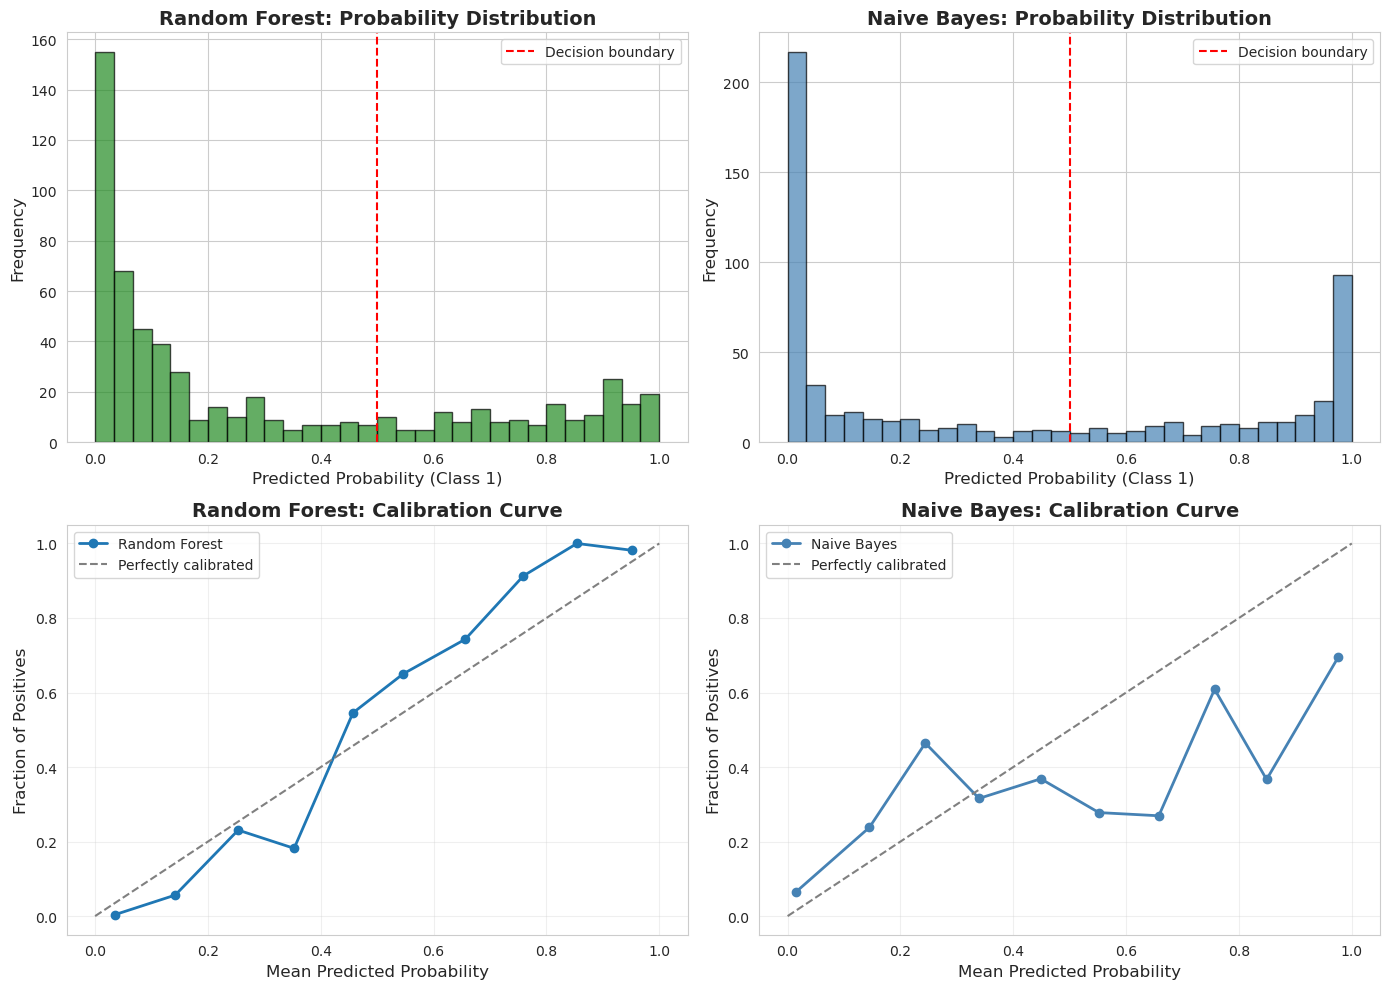


 Calibration Analysis:
   A well-calibrated model: when it says 70% confidence, it's right 70% of the time
   Random Forest: Generally well-calibrated (close to diagonal)
   Naive Bayes: May be poorly calibrated due to independence assumption


In [18]:
# Analyze probability distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Probability distributions for Random Forest
axes[0, 0].hist(probs_rf[:, 1], bins=30, alpha=0.7, color='forestgreen', edgecolor='black')
axes[0, 0].set_xlabel('Predicted Probability (Class 1)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Random Forest: Probability Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', label='Decision boundary')
axes[0, 0].legend()

# Plot 2: Probability distributions for Naive Bayes
axes[0, 1].hist(probs_nb[:, 1], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Predicted Probability (Class 1)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Naive Bayes: Probability Distribution', fontsize=14, fontweight='bold')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', label='Decision boundary')
axes[0, 1].legend()

# Plot 3: Calibration curve for Random Forest
from sklearn.calibration import calibration_curve

prob_true_rf, prob_pred_rf = calibration_curve(y_test, probs_rf[:, 1], n_bins=10)
axes[1, 0].plot(prob_pred_rf, prob_true_rf, marker='o', linewidth=2, label='Random Forest')
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
axes[1, 0].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1, 0].set_ylabel('Fraction of Positives', fontsize=12)
axes[1, 0].set_title('Random Forest: Calibration Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Calibration curve for Naive Bayes
prob_true_nb, prob_pred_nb = calibration_curve(y_test, probs_nb[:, 1], n_bins=10)
axes[1, 1].plot(prob_pred_nb, prob_true_nb, marker='o', linewidth=2, label='Naive Bayes', color='steelblue')
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
axes[1, 1].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1, 1].set_ylabel('Fraction of Positives', fontsize=12)
axes[1, 1].set_title('Naive Bayes: Calibration Curve', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Calibration Analysis:")
print("   A well-calibrated model: when it says 70% confidence, it's right 70% of the time")
print("   Random Forest: Generally well-calibrated (close to diagonal)")
print("   Naive Bayes: May be poorly calibrated due to independence assumption")

## Why Do Different Models Behave Differently?

### Summary of Key Differences:

| Aspect | Decision Tree | Random Forest | Naive Bayes |
|--------|--------------|---------------|-------------|
| **Learning Approach** | Greedy recursive splitting | Ensemble of trees | Probabilistic (Bayes' theorem) |
| **Overfitting Risk** | ⚠️ Very High | ✅ Low | ✅ Low (high bias) |
| **Stability** | ❌ Unstable | ✅ Very stable | ✅ Stable |
| **Interpretability** | ✅ Easy | ⚠️ Moderate | ✅ Easy |
| **Training Speed** | ✅ Fast | ⚠️ Slower | ✅ Very fast |
| **Probability Estimates** | ⚠️ Poor | ✅ Good | ⚠️ Can be poor |
| **Feature Interactions** | ✅ Captures well | ✅ Captures well | ❌ Assumes independence |

###  When to Use Each Model:

**Decision Tree**:
- ✅ Need interpretability
- ✅ Small dataset
- ✅ Quick baseline
- ❌ Production systems (too unstable)

**Random Forest**:
- ✅ Need high accuracy
- ✅ Have computational resources
- ✅ Need feature importance
- ✅ Production systems
- ❌ Need real-time predictions (slower)

**Naive Bayes**:
- ✅ Text classification
- ✅ Need speed
- ✅ Features are actually independent
- ✅ Small training data
- ❌ Complex feature interactions

##  Final Experiment: All Models on Real Data

Let's test everything on the Breast Cancer dataset!

In [20]:
# Load real dataset
data = load_breast_cancer()
X_real, y_real = data.data, data.target
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, random_state=42
)

print("🏥 Breast Cancer Dataset:")
print(f"   Samples: {X_real.shape[0]}")
print(f"   Features: {X_real.shape[1]}")
print(f"   Classes: {data.target_names}\n")

# Train all models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train_real, y_train_real)
    pred = model.predict(X_test_real)
    probs = model.predict_proba(X_test_real)
    
    results[name] = {
        'accuracy': accuracy_score(y_test_real, pred),
        'precision': precision_score(y_test_real, pred),
        'recall': recall_score(y_test_real, pred),
        'log_loss': log_loss(y_test_real, probs)
    }

# Display results
results_df = pd.DataFrame(results).T
print(" Model Comparison on Real Data:")
print(results_df.round(4))
print("\n Best Model:", results_df['accuracy'].idxmax())

🏥 Breast Cancer Dataset:
   Samples: 569
   Features: 30
   Classes: ['malignant' 'benign']

 Model Comparison on Real Data:
               accuracy  precision  recall  log_loss
Decision Tree    0.9415     0.9712  0.9352    2.1078
Random Forest    0.9708     0.9640  0.9907    0.0939
Naive Bayes      0.9415     0.9455  0.9630    0.4899

 Best Model: Random Forest


/tmp/ipykernel_15801/2314032571.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(results_df.index, rotation=0)


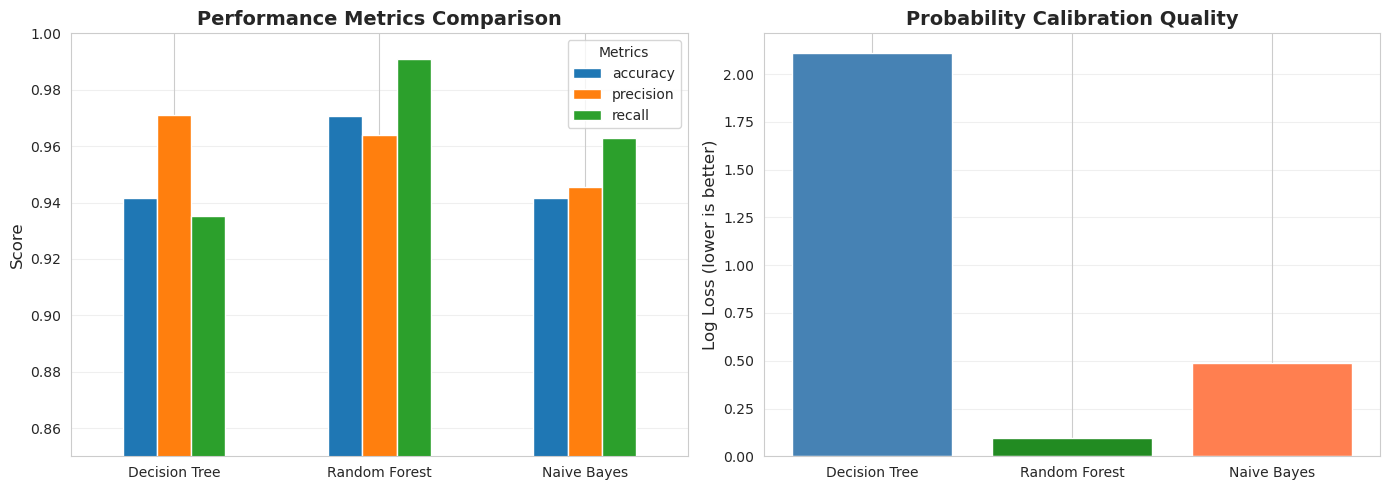

In [21]:
# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metrics comparison
results_df[['accuracy', 'precision', 'recall']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].legend(title='Metrics')
axes[0].set_ylim([0.85, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Log loss comparison (lower is better)
axes[1].bar(results_df.index, results_df['log_loss'], color=['steelblue', 'forestgreen', 'coral'])
axes[1].set_ylabel('Log Loss (lower is better)', fontsize=12)
axes[1].set_title('Probability Calibration Quality', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(results_df.index, rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 🎓 Key Takeaways

### 1. **Ensemble Methods Reduce Variance**
   - Random Forest averages many high-variance trees
   - Result: Lower overfitting, better generalization

### 2. **Model Assumptions Matter**
   - Naive Bayes assumes feature independence
   - When violated: predictions may be good, but probabilities unreliable

### 3. **Stability vs Flexibility Tradeoff**
   - Decision Tree: Flexible but unstable
   - Random Forest: Flexible AND stable (best of both worlds)
   - Naive Bayes: Stable but inflexible

### 4. **Different Metrics Tell Different Stories**
   - Accuracy: Overall correctness
   - Log Loss: Quality of probability estimates
   - Always use multiple metrics!

### 5. **No Free Lunch Theorem**
   - No single model is best for all problems
   - Understand your data and requirements
   - Experiment and compare!

---

##  Practice Exercises

1. **Experiment with tree depth**: Try `max_depth=5, 10, 20` for both DT and RF. How does it affect overfitting?

2. **Feature engineering**: Create interaction features (e.g., `X[:, 0] * X[:, 1]`). Does Naive Bayes improve?

3. **Ensemble size**: Plot RF accuracy vs number of trees (10, 50, 100, 200, 500). When do returns diminish?

4. **Cross-validation**: Use 5-fold CV to get more robust performance estimates

5. **Imbalanced data**: Create a 95-5 split. Which model handles it best?